# Symmetry-Adapted Orbit-Tied Operators

This notebook enables **orbit-tied** `K_self` factors on graphs with
automorphism symmetry: auto-detected orbits vs an identity partition
(one orbit per node) vs the default shared `K_self`. We report parameter
counts, effective spectra, a multi-orbit (star) contrast, and a
matched-budget holdout comparison on a Kuramoto–Sivashinsky ring — claiming
sample-efficiency only when the short-train gap clears a stated RMSE
margin (`RMSE_WIN_EPS`).

**Prerequisites**

```bash
pip install "koopman-graph[symmetry]"   # networkx for method="auto"
# optional: pynauty for method="exact"
```

Without `[symmetry]`, `node_orbit_partition` warns and falls back to the
identity partition (demonstrated below). Theory: Salova et al., *Chaos* 2019
(`Salova2019`); background Koopman vocabulary in Budišić et al. (`Budisic2012`).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random
from unittest.mock import patch

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import KuramotoSivashinskyBenchmark
from koopman_graph.graph_utils import (
    identity_orbit_partition,
    node_orbit_partition,
)
from koopman_graph.operators import GraphKoopmanOperator

try:
    import networkx  # noqa: F401

    SYMMETRY_AVAILABLE = True
except ImportError:
    SYMMETRY_AVAILABLE = False

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 35
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

N_NODES = 8 if IS_TEST else 16
LATENT_DIM = 2 if IS_TEST else 4
EPOCHS = 2 if IS_TEST else 30
T_SHORT = 12 if IS_TEST else 24
T_FULL = 20 if IS_TEST else 48
HOLDOUT = 4 if IS_TEST else 8
print(
    f"IS_TEST={IS_TEST}  SYMMETRY_AVAILABLE={SYMMETRY_AVAILABLE}  "
    f"N={N_NODES}  d={LATENT_DIM}"
)
if not SYMMETRY_AVAILABLE:
    print('Install orbits backend: pip install "koopman-graph[symmetry]"')


IS_TEST=False  SYMMETRY_AVAILABLE=True  N=16  d=4


## Motivation and background

Networks with automorphism symmetry (e.g. a ring or star) induce **node
orbits**. Salova et al. (`Salova2019`) show how symmetries structure the
Koopman operator and its EDMD approximations. KoopmanGraph's practical bias:
nodes in the same orbit share a `K_self` bank entry
(`koopman_auto_orbits=True` or an explicit `koopman_orbit_partition`).
Neighbor coupling `K_nbr` stays shared.

Default `koopman="graph"` already uses **one** shared `K_self`. On a
vertex-transitive ring, auto orbits collapse to that same single factor —
orbit ties mainly matter when you would otherwise allocate **per-node**
factors (identity partition) or when **multiple orbits** need distinct self
dynamics (e.g. a star: hub vs leaves).


## Minimal example: fallback + ring param counts

When `networkx` / `pynauty` are unavailable, auto orbits warn and return the
identity partition (no tying). On a cycle with `[symmetry]`, auto orbits
collapse to one orbit — far fewer `K_self` parameters than identity.


In [2]:
edge_probe = KuramotoSivashinskyBenchmark.generate(
    num_nodes=N_NODES,
    num_timesteps=4,
    topology="ring",
    burn_in=2 if IS_TEST else 20,
    seed=SEED,
)[0].edge_index

real_import = __import__


def _block_symmetry_backends(name, *args, **kwargs):
    if name in {"networkx", "pynauty"}:
        raise ImportError(f"blocked {name}")
    return real_import(name, *args, **kwargs)


with (
    patch("builtins.__import__", side_effect=_block_symmetry_backends),
    warnings.catch_warnings(record=True) as caught,
):
    warnings.simplefilter("always")
    fallback = node_orbit_partition(edge_probe, N_NODES, method="auto")

print(f"fallback partition (#orbits={len(fallback)}): {fallback[:3]}...")
print(f"equals identity? {fallback == identity_orbit_partition(N_NODES)}")
print(f"warnings emitted: {len(caught)}")
if caught:
    print(f"  e.g. {caught[0].message}")


fallback partition (#orbits=16): ((0,), (1,), (2,))...
equals identity? True
warnings emitted: 1
  e.g. Neither pynauty nor networkx is available; using identity orbit partition. Install with: pip install 'koopman-graph[symmetry]'


In [3]:
def trainable_params(module: torch.nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


if SYMMETRY_AVAILABLE:
    auto_part = node_orbit_partition(edge_probe, N_NODES, method="auto")
else:
    auto_part = identity_orbit_partition(N_NODES)
    print("Using identity partition (no networkx).")

print(f"auto partition (#orbits={len(auto_part)}): {auto_part}")

tied = GraphKoopmanOperator(LATENT_DIM, init_mode="identity", auto_orbits=True)
ident = GraphKoopmanOperator(
    LATENT_DIM,
    init_mode="identity",
    orbit_partition=identity_orbit_partition(N_NODES),
)
shared = GraphKoopmanOperator(LATENT_DIM, init_mode="identity")

z0 = torch.zeros(N_NODES, LATENT_DIM)
_ = tied.advance(z0, edge_index=edge_probe)
_ = ident.advance(z0, edge_index=edge_probe)

param_counts = {
    "auto_orbits": trainable_params(tied),
    "identity_partition": trainable_params(ident),
    "default_shared": trainable_params(shared),
}
print("Operator trainable parameters (ring):")
for name, n in param_counts.items():
    print(f"  {name:22s}  {n}")
print(
    f"reduction auto vs identity: "
    f"{1 - param_counts['auto_orbits'] / param_counts['identity_partition']:.1%}"
)


auto partition (#orbits=1): ((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15),)
Operator trainable parameters (ring):
  auto_orbits             32
  identity_partition      272
  default_shared          32
reduction auto vs identity: 88.2%


## Progressive deep dive

Spectra under matched factors, a multi-orbit star (where orbit ties differ
from default shared), then a KS-ring holdout comparison at matched budgets.


### Spectra: one-orbit ties match default shared $K_{\mathrm{self}}$

With identical dense factors, auto-orbit (one ring orbit) and default shared
operators share the same effective spectrum — tying is an inductive bias, not
different physics.


In [4]:
torch.manual_seed(SEED)
k_self = 0.7 * torch.eye(LATENT_DIM) + 0.05 * torch.randn(LATENT_DIM, LATENT_DIM)
k_nbr = 0.05 * torch.eye(LATENT_DIM)

tied_s = GraphKoopmanOperator(LATENT_DIM, init_mode="identity", auto_orbits=True)
shared_s = GraphKoopmanOperator(LATENT_DIM, init_mode="identity")
_ = tied_s.advance(torch.zeros(N_NODES, LATENT_DIM), edge_index=edge_probe)
tied_s.set_dense_matrices(k_self, k_nbr)
shared_s.set_dense_matrices(k_self, k_nbr)

eig_tied = tied_s.spectrum(edge_probe, N_NODES).eigenvalues.detach().cpu()
eig_shared = shared_s.spectrum(edge_probe, N_NODES).eigenvalues.detach().cpu()
spec_err = float((eig_tied - eig_shared).abs().max().item())
print(f"max |λ_tied − λ_shared| = {spec_err:.2e}")
print(f"spectrum size = {eig_tied.numel()} (= N·d)")


max |λ_tied − λ_shared| = 0.00e+00
spectrum size = 64 (= N·d)


### Multi-orbit contrast (star)

A star has two orbits (hub; leaves). Auto orbits allocate **two** `K_self`
banks — still far fewer than identity, and **more** than default shared
(one bank). This is the regime where orbit ties are not redundant with
`koopman="graph"` defaults.


In [5]:
n_star = 5 if IS_TEST else 9
star_edges: list[list[int]] = []
for leaf in range(1, n_star):
    star_edges.extend([[0, leaf], [leaf, 0]])
star_ei = torch.tensor(star_edges, dtype=torch.long).t().contiguous()

if SYMMETRY_AVAILABLE:
    star_part = node_orbit_partition(star_ei, n_star, method="auto")
else:
    star_part = identity_orbit_partition(n_star)
print(f"star partition (#orbits={len(star_part)}): {star_part}")

star_tied = GraphKoopmanOperator(
    LATENT_DIM, init_mode="identity", auto_orbits=True
)
star_ident = GraphKoopmanOperator(
    LATENT_DIM,
    init_mode="identity",
    orbit_partition=identity_orbit_partition(n_star),
)
star_shared = GraphKoopmanOperator(LATENT_DIM, init_mode="identity")
_ = star_tied.advance(torch.zeros(n_star, LATENT_DIM), edge_index=star_ei)

star_counts = {
    "auto_orbits": trainable_params(star_tied),
    "identity_partition": trainable_params(star_ident),
    "default_shared": trainable_params(star_shared),
}
print("Operator trainable parameters (star):")
for name, n in star_counts.items():
    print(f"  {name:22s}  {n}")


star partition (#orbits=2): ((0,), (1, 2, 3, 4, 5, 6, 7, 8))
Operator trainable parameters (star):
  auto_orbits             48
  identity_partition      160
  default_shared          32


### Kuramoto–Sivashinsky ring data

Compact KS trajectory on a ring overlay. Short vs longer train prefixes for
the sample-budget check. On this ring, auto orbits ≡ one shared `K_self` by
construction — expect holdout RMSE near the default shared baseline when both
train fairly (`fit` binds auto orbits before the optimizer).


In [6]:
ks = KuramotoSivashinskyBenchmark.generate(
    num_nodes=N_NODES,
    num_timesteps=T_FULL + HOLDOUT,
    topology="ring",
    burn_in=5 if IS_TEST else 50,
    dt=0.25,
    seed=SEED,
)
train_short = ks.slice(0, T_SHORT)
train_full = ks.slice(0, T_FULL)
holdout = ks.slice(T_FULL, T_FULL + HOLDOUT)
edge_index = ks[0].edge_index
print(
    f"KS T={ks.num_timesteps}  short={train_short.num_timesteps}  "
    f"full={train_full.num_timesteps}  holdout={holdout.num_timesteps}"
)


KS T=56  short=24  full=48  holdout=8


### Sample-budget comparison (matched epochs)

Fit orbit-tied (`koopman_auto_orbits=True`) vs identity-partition vs default
shared models with the same encoder/decoder width and epoch count on the
**short** train prefix; evaluate one-step RMSE on the chronological holdout.
Also fit on the full train prefix for context. Claim sample-efficiency only if
auto beats identity on the short split by at least `RMSE_WIN_EPS` (absolute
holdout RMSE); smaller single-seed gaps are printed as near-ties / non-claims.


In [7]:
def make_graph_model(*, orbit_mode: str) -> GraphKoopmanModel:
    kwargs = dict(
        encoder=GNNEncoder(1, 16, LATENT_DIM, num_layers=2),
        decoder=GNNDecoder(LATENT_DIM, 16, 1, num_layers=2),
        latent_dim=LATENT_DIM,
        time_step=0.25,
        koopman="graph",
    )
    if orbit_mode == "auto":
        return GraphKoopmanModel(
            **kwargs,
            koopman_auto_orbits=True,
            koopman_orbit_method="auto",
        )
    if orbit_mode == "identity":
        return GraphKoopmanModel(
            **kwargs,
            koopman_orbit_partition=identity_orbit_partition(N_NODES),
        )
    return GraphKoopmanModel(**kwargs)


def one_step_rmse(model: GraphKoopmanModel, sequence) -> float:
    errs = []
    model.eval()
    with torch.no_grad():
        for t in range(sequence.num_timesteps - 1):
            pred = model(sequence[t])
            target = sequence[t + 1].x
            errs.append(torch.mean((pred - target) ** 2))
    return float(torch.sqrt(torch.stack(errs).mean()).item())


results = {}
for budget_name, train_seq in [("short", train_short), ("full", train_full)]:
    results[budget_name] = {}
    for mode in ("auto", "identity", "shared"):
        torch.manual_seed(SEED)
        model = make_graph_model(orbit_mode=mode)
        _ = model.fit(train_seq, epochs=EPOCHS, lr=1e-3)
        results[budget_name][mode] = {
            "holdout_rmse": one_step_rmse(model, holdout),
            "n_params_op": trainable_params(model.koopman),
            "n_orbits": len(model.koopman.orbit_partition or ()),
        }

print("Holdout one-step RMSE (matched epochs):")
for budget_name, modes in results.items():
    print(f"  [{budget_name} train]")
    for mode, row in modes.items():
        print(
            f"    {mode:10s}  RMSE={row['holdout_rmse']:.6f}  "
            f"op_params={row['n_params_op']}  orbits={row['n_orbits']}"
        )

# Absolute holdout-RMSE margin required before claiming a short-train win.
# Sub-threshold gaps are single-seed noise on this ring demo (often ~0.01).
RMSE_WIN_EPS = 0.02

short_auto = results["short"]["auto"]["holdout_rmse"]
short_ident = results["short"]["identity"]["holdout_rmse"]
short_shared = results["short"]["shared"]["holdout_rmse"]
short_delta = short_ident - short_auto
full_auto = results["full"]["auto"]["holdout_rmse"]
full_ident = results["full"]["identity"]["holdout_rmse"]

if short_delta >= RMSE_WIN_EPS:
    print(
        f"Sample-efficiency (measured): auto_orbits beats identity on short "
        f"train by {short_delta:.4f} ≥ eps={RMSE_WIN_EPS:g} "
        f"({short_auto:.4f} vs {short_ident:.4f})."
    )
elif short_delta > 0:
    print(
        f"Sample-efficiency (measured): short-train gap is a near-tie "
        f"(Δ={short_delta:.4f} < eps={RMSE_WIN_EPS:g}; "
        f"{short_auto:.4f} vs {short_ident:.4f}) — non-claim; "
        "param reduction still holds."
    )
else:
    print(
        f"Sample-efficiency (measured): auto_orbits did not beat identity on "
        f"this seed/budget ({short_auto:.4f} vs {short_ident:.4f}) — "
        "non-claim; param reduction still holds."
    )
print(
    f"Budget check: full-train auto vs identity = "
    f"{full_auto:.4f} vs {full_ident:.4f} "
    f"(ranking may flip vs short; do not claim from short alone)."
)
print(
    f"Ring sanity: |RMSE_auto − RMSE_shared| (short) = "
    f"{abs(short_auto - short_shared):.4f} "
    "(expect small when both train with one shared K_self)."
)


Holdout one-step RMSE (matched epochs):
  [short train]
    auto        RMSE=0.894536  op_params=32  orbits=1
    identity    RMSE=0.898747  op_params=272  orbits=16
    shared      RMSE=0.896685  op_params=32  orbits=0
  [full train]
    auto        RMSE=0.891930  op_params=32  orbits=1
    identity    RMSE=0.891288  op_params=272  orbits=16
    shared      RMSE=0.896216  op_params=32  orbits=0
Sample-efficiency (measured): short-train gap is a near-tie (Δ=0.0042 < eps=0.02; 0.8945 vs 0.8987) — non-claim; param reduction still holds.
Budget check: full-train auto vs identity = 0.8919 vs 0.8913 (ranking may flip vs short; do not claim from short alone).
Ring sanity: |RMSE_auto − RMSE_shared| (short) = 0.0021 (expect small when both train with one shared K_self).


## Results

**Left:** operator-only parameter counts on the ring — `auto_orbits` matches
`default_shared` (one `K_self`); identity is about $N$ times larger.

**Right:** holdout one-step RMSE for short vs full train. On this
vertex-transitive ring, auto and shared should be close; all three bars are
often within a few percent. The stdout gate claims a sample-efficiency win
only when short-train `RMSE_identity − RMSE_auto ≥ RMSE_WIN_EPS`; otherwise
it reports a near-tie / non-claim (see also the full-train ranking check).


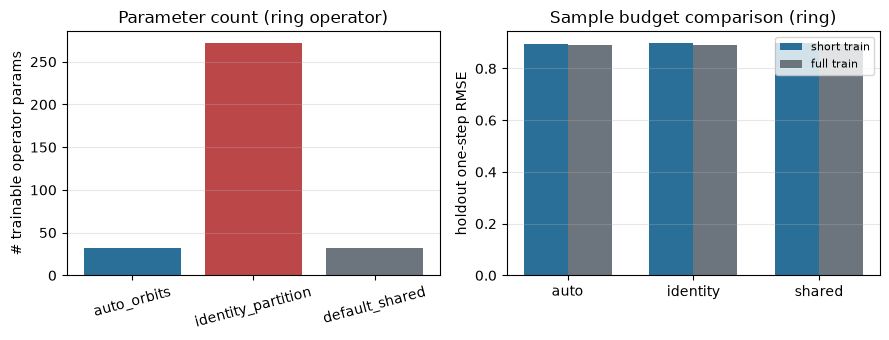

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

labels = list(param_counts.keys())
axes[0].bar(
    labels,
    [param_counts[k] for k in labels],
    color=["#2a6f97", "#bc4749", "#6c757d"],
)
axes[0].set_ylabel("# trainable operator params")
axes[0].set_title("Parameter count (ring operator)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

modes = ["auto", "identity", "shared"]
x = np.arange(len(modes))
w = 0.35
axes[1].bar(
    x - w / 2,
    [results["short"][m]["holdout_rmse"] for m in modes],
    width=w,
    label="short train",
    color="#2a6f97",
)
axes[1].bar(
    x + w / 2,
    [results["full"][m]["holdout_rmse"] for m in modes],
    width=w,
    label="full train",
    color="#6c757d",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modes)
axes[1].set_ylabel("holdout one-step RMSE")
axes[1].set_title("Sample budget comparison (ring)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## Interpretation

- **Parameter reduction** vs identity is structural on a ring (one orbit ⇒
  one `K_self`). Default shared already has that count — orbit ties shine
  when comparing against per-node factors or on **multi-orbit** graphs (star
  demo above: two banks vs one shared vs $N$ identity).
- **Spectra:** one-orbit ties reproduce the shared-operator spectrum when
  factors match.
- **Sample efficiency** on this ring is seed- and budget-dependent and is
  often a near-tie with default shared (and with identity at matched epochs).
  Only claim a win when the short-train gap clears `RMSE_WIN_EPS` **and**
  check that full-train ranking does not reverse the story. Prefer stars /
  heterogeneous orbits when testing whether tying beats an over-parameterized
  identity bank.
- Approximate WL orbits (`method="auto"`) can mis-tie blocks — treat as a
  bias, not a certificate of the true automorphism group (`Salova2019`).


## Takeaways

- Install `[symmetry]` for auto orbits; without it you get a warned identity
  fallback (no tying).
- Use `koopman_auto_orbits=True` or an explicit `koopman_orbit_partition` when
  you want orbit-tied `K_self` (stars, multi-orbit graphs, or vs per-node
  identity banks). On a vertex-transitive ring, auto ≈ default shared —
  prefer shared unless you need the orbit API for serialization / mixed
  topologies.
- Report operator parameter counts and spectra; claim sample-efficiency only
  from measured holdout RMSE at matched budgets when the short-train gap
  exceeds `RMSE_WIN_EPS` (near-ties stay non-claims).
- Gotcha: `fit` binds `auto_orbits` from the first train snapshot **before**
  building the optimizer so orbit `K_self` is trained; do not rely on a
  post-fit `advance` to “activate” ties for learning.
- Citations: `Salova2019`, `Budisic2012`.


## Further reading

- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html) —
  `koopman_auto_orbits`, `koopman_orbit_partition`,
  `node_orbit_partition`, `GraphKoopmanOperator`
- [Architecture](https://koopmangraph.readthedocs.io/en/latest/architecture.html) —
  symmetry-adapted orbit ties
- Related:
  [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb)
- Citations (`paper.bib`): `Salova2019`, `Budisic2012`
